# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
165,-0.041840,-0.044642,-0.066563,-0.046985,-0.037344,-0.043276,0.048640,-0.039493,-0.056153,-0.013504,59.0
298,0.023546,0.050680,-0.037463,-0.046985,-0.091006,-0.075530,-0.032356,-0.039493,-0.030748,-0.013504,129.0
191,-0.005515,0.050680,-0.041774,-0.043542,-0.079998,-0.076156,-0.032356,-0.039493,0.010227,-0.009362,178.0
360,0.016281,-0.044642,0.020739,0.021872,-0.013953,-0.013214,-0.006584,-0.002592,0.013317,0.040343,281.0
154,0.067136,0.050680,0.020739,-0.005670,0.020446,0.026243,-0.002903,-0.002592,0.008641,0.003064,197.0
247,-0.081798,-0.044642,-0.081653,-0.040099,0.002559,-0.018537,0.070730,-0.039493,-0.010903,-0.092204,51.0
174,0.016281,0.050680,0.009961,-0.043542,-0.096510,-0.094632,-0.039719,-0.039493,0.017036,0.007207,151.0
37,-0.009147,-0.044642,0.011039,-0.057313,-0.024960,-0.042963,0.030232,-0.039493,0.017036,-0.005220,276.0
391,-0.023677,-0.044642,-0.069797,-0.064199,-0.059359,-0.050478,0.019187,-0.039493,-0.089133,-0.050783,63.0
187,-0.067268,-0.044642,-0.054707,-0.026328,-0.075870,-0.082106,0.048640,-0.076395,-0.086827,-0.104630,143.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [6]:
data.isnull().sum()


age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [8]:
imputer_media = SimpleImputer(strategy='mean')
data['bmi'] = imputer_media.fit_transform(data[['bmi']])

print("Valores faltantes en 'bmi' después de imputación:", data['bmi'].isnull().sum())


Valores faltantes en 'bmi' después de imputación: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [10]:
# Recrear datos con valores faltantes para comparar
data_knn = diabetes.data.copy()
data_knn['target'] = diabetes.target
np.random.seed(42)
data_knn.loc[data_knn.sample(frac=0.1).index, 'bmi'] = np.nan
data_knn.loc[data_knn.sample(frac=0.1).index, 'bp'] = np.nan

# Imputación con media (para comparar)
data_media = data_knn.copy()
imputer_media2 = SimpleImputer(strategy='mean')
data_media[['bmi', 'bp']] = imputer_media2.fit_transform(data_media[['bmi', 'bp']])

# Imputación con KNN
data_knn_imp = data_knn.copy()
knn_imputer = KNNImputer(n_neighbors=5)
data_knn_imp[['bmi', 'bp']] = knn_imputer.fit_transform(data_knn_imp[['bmi', 'bp']])

# Comparación
print("=== Comparación en 'bmi' (solo filas que tenían NaN) ===")
mask_bmi = data_knn['bmi'].isnull()
comparacion_bmi = pd.DataFrame({
    'Media': data_media.loc[mask_bmi, 'bmi'].values,
    'KNN':   data_knn_imp.loc[mask_bmi, 'bmi'].values
})
print(comparacion_bmi.head(10))

print("\n=== Comparación en 'bp' (solo filas que tenían NaN) ===")
mask_bp = data_knn['bp'].isnull()
comparacion_bp = pd.DataFrame({
    'Media': data_media.loc[mask_bp, 'bp'].values,
    'KNN':   data_knn_imp.loc[mask_bp, 'bp'].values
})
print(comparacion_bp.head(10))


=== Comparación en 'bmi' (solo filas que tenían NaN) ===
      Media       KNN
0 -0.000205 -0.021080
1 -0.000205 -0.000205
2 -0.000205 -0.000205
3 -0.000205  0.000045
4 -0.000205 -0.006422
5 -0.000205 -0.006422
6 -0.000205  0.009099
7 -0.000205 -0.036600
8 -0.000205  0.038847
9 -0.000205  0.001985

=== Comparación en 'bp' (solo filas que tenían NaN) ===
      Media       KNN
0  0.000465  0.003970
1  0.000465 -0.018292
2  0.000465 -0.008425
3  0.000465  0.048038
4  0.000465  0.000465
5  0.000465  0.000465
6  0.000465 -0.030686
7  0.000465 -0.026100
8  0.000465 -0.050427
9  0.000465 -0.042165


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

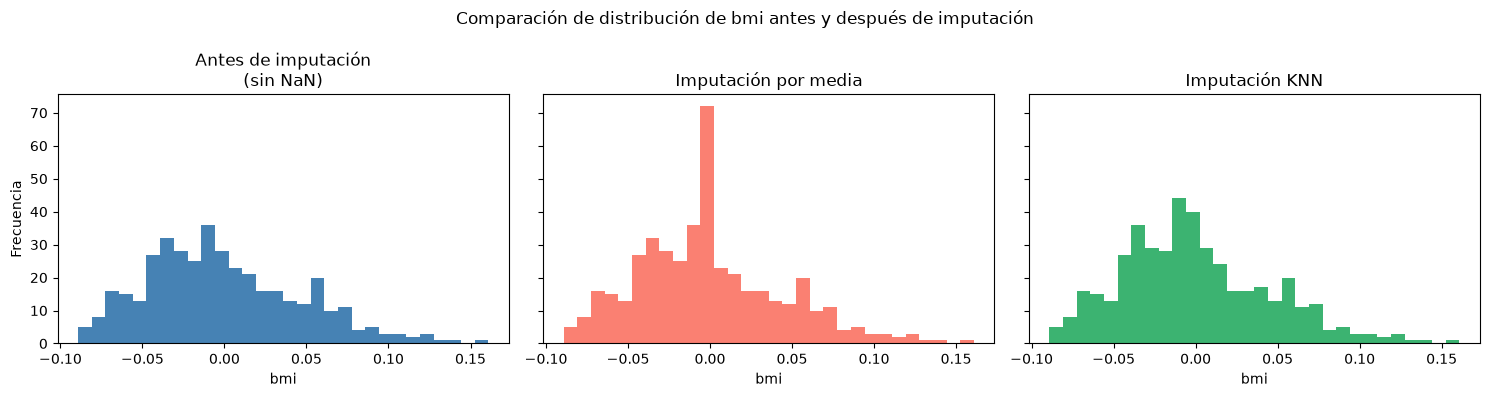

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(data_knn['bmi'].dropna(), bins=30, color='steelblue')
axes[0].set_title('Antes de imputación\n(sin NaN)')
axes[0].set_xlabel('bmi')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(data_media['bmi'], bins=30, color='salmon')
axes[1].set_title('Imputación por media')
axes[1].set_xlabel('bmi')

axes[2].hist(data_knn_imp['bmi'], bins=30, color='mediumseagreen')
axes[2].set_title('Imputación KNN')
axes[2].set_xlabel('bmi')

plt.suptitle('Comparación de distribución de bmi antes y después de imputación')
plt.tight_layout()
plt.show()
